## UCI Distribution Analysis

목적: UCI Online Retail로 SKU 다품종 분포 확인하기 위한 코드

In [11]:
%pip install openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]

Note: you may need to restart the kernel to use updated packages.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

In [13]:
DATA_DIR = Path("../data/raw")

ITEMS_PATH = DATA_DIR / "olist_order_items_dataset.csv"
ORDERS_PATH = DATA_DIR / "olist_orders_dataset.csv"
PRODUCTS_PATH = DATA_DIR / "olist_products_dataset.csv"
SELLERS_PATH = DATA_DIR / "olist_sellers_dataset.csv"
UCI_PATH = DATA_DIR / "Online Retail.xlsx"

In [14]:
print(UCI_PATH)
print(UCI_PATH.exists())

..\data\raw\Online Retail.xlsx
True


In [16]:
uci = pd.read_excel(UCI_PATH)

# 취소 거래 제거
uci = uci[~uci["InvoiceNo"].astype(str).str.startswith("C")]

# 0 이하 수량 제거
uci = uci[uci["Quantity"] > 0]

# 주문당 distinct SKU 수
sku_per_invoice = (
    uci.groupby("InvoiceNo")["StockCode"]
       .nunique()
)

ratio = (
    sku_per_invoice
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

display(ratio)

StockCode
1       11.530297
2        4.023543
3        3.333655
4        3.198572
5        3.319182
          ...    
704      0.004824
721      0.004824
731      0.004824
749      0.004824
1110     0.004824
Name: proportion, Length: 366, dtype: float64

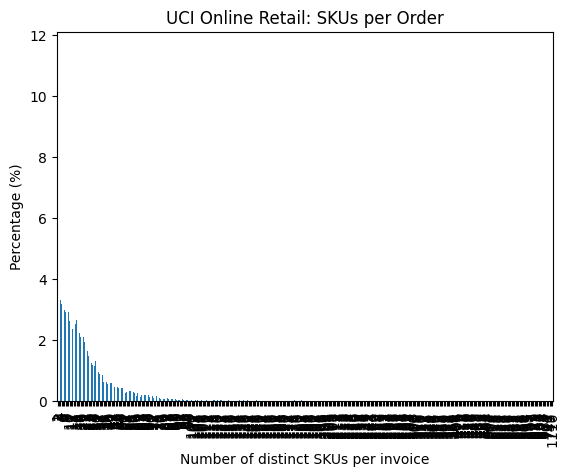

In [17]:
ratio.plot(kind="bar")

plt.xlabel("Number of distinct SKUs per invoice")
plt.ylabel("Percentage (%)")
plt.title("UCI Online Retail: SKUs per Order")
plt.show()

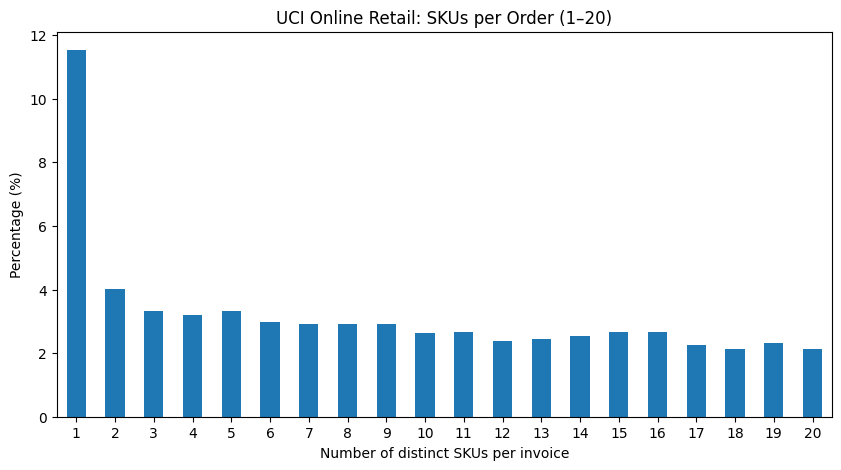

Orders with more than 20 SKUs: 36.06%


In [18]:
# 1~20 SKU 주문만 시각화
ratio_20 = ratio[ratio.index <= 20]

plt.figure(figsize=(10, 5))
ratio_20.plot(kind="bar")

plt.xlabel("Number of distinct SKUs per invoice")
plt.ylabel("Percentage (%)")
plt.title("UCI Online Retail: SKUs per Order (1–20)")
plt.xticks(rotation=0)
plt.show()

# 20개 초과 주문 비율
over_20 = ratio[ratio.index > 20].sum()
print(f"Orders with more than 20 SKUs: {over_20:.2f}%")

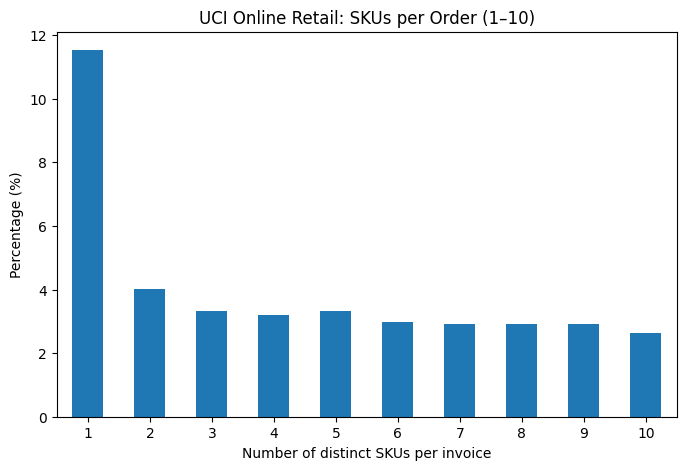

In [19]:
ratio_10 = ratio[ratio.index <= 10]

plt.figure(figsize=(8, 5))
ratio_10.plot(kind="bar")

plt.xlabel("Number of distinct SKUs per invoice")
plt.ylabel("Percentage (%)")
plt.title("UCI Online Retail: SKUs per Order (1–10)")
plt.xticks(rotation=0)
plt.show()

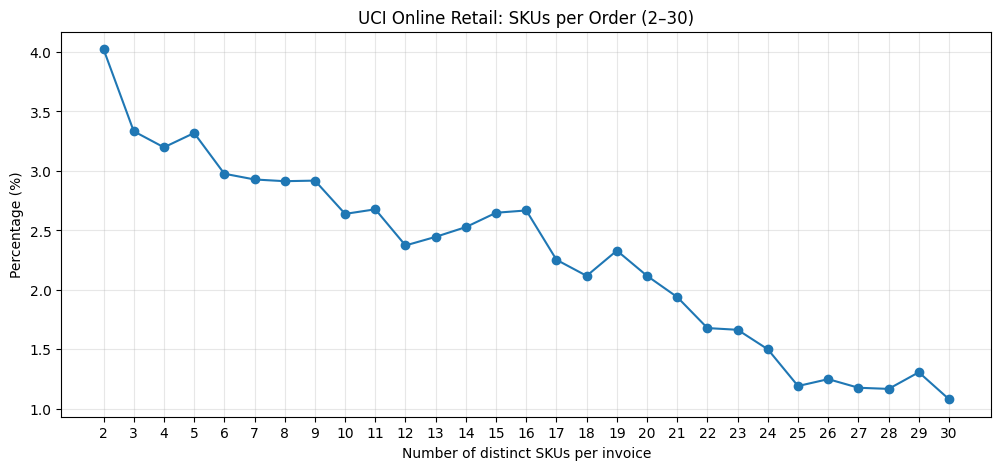

In [20]:
# 1-SKU 제외 + 2~30 SKU만 확대
ratio_zoom = ratio[(ratio.index >= 2) & (ratio.index <= 30)]

plt.figure(figsize=(12, 5))
plt.plot(
    ratio_zoom.index,
    ratio_zoom.values,
    marker="o"
)

plt.xlabel("Number of distinct SKUs per invoice")
plt.ylabel("Percentage (%)")
plt.title("UCI Online Retail: SKUs per Order (2–30)")
plt.xticks(range(2, 31))
plt.grid(alpha=0.3)
plt.show()

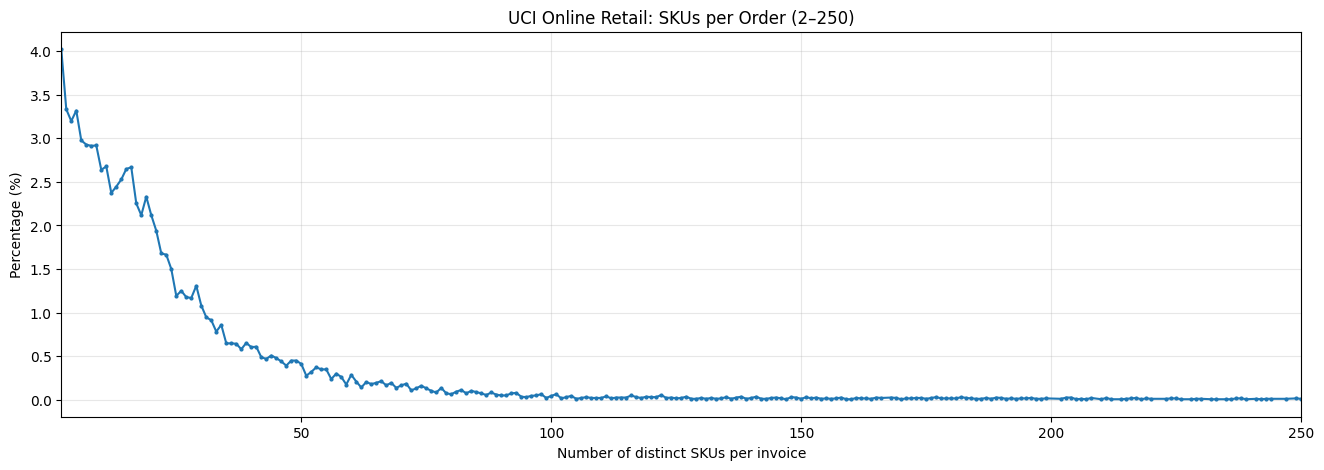

In [21]:
ratio_2_250 = ratio[(ratio.index >= 2) & (ratio.index <= 250)]

plt.figure(figsize=(16, 5))
plt.plot(
    ratio_2_250.index,
    ratio_2_250.values,
    marker="o",
    markersize=2
)

plt.xlabel("Number of distinct SKUs per invoice")
plt.ylabel("Percentage (%)")
plt.title("UCI Online Retail: SKUs per Order (2–250)")
plt.xlim(2, 250)
plt.grid(alpha=0.3)
plt.show()

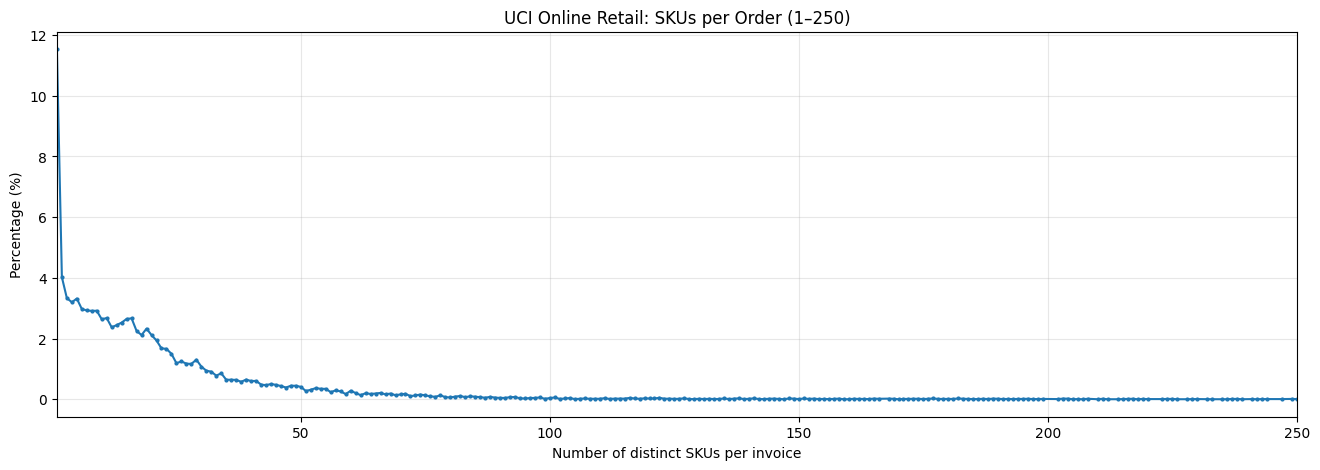

In [22]:
ratio_1_250 = ratio[(ratio.index >= 1) & (ratio.index <= 250)]

plt.figure(figsize=(16, 5))
plt.plot(
    ratio_1_250.index,
    ratio_1_250.values,
    marker="o",
    markersize=2
)

plt.xlabel("Number of distinct SKUs per invoice")
plt.ylabel("Percentage (%)")
plt.title("UCI Online Retail: SKUs per Order (1–250)")
plt.xlim(1, 250)
plt.grid(alpha=0.3)
plt.show()

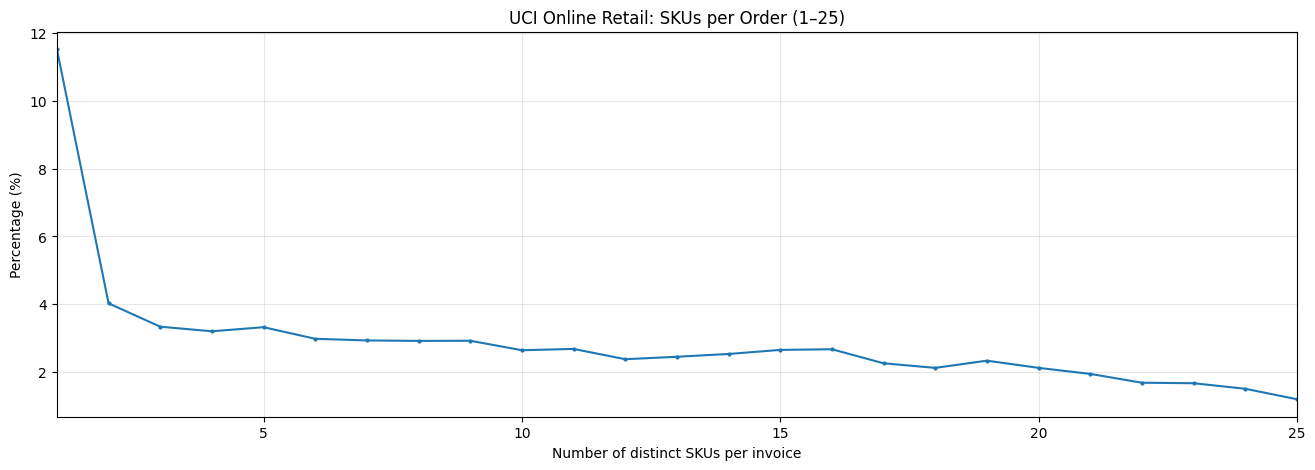

In [26]:
ratio_1_25 = ratio[(ratio.index >= 1) & (ratio.index <= 25)]

plt.figure(figsize=(16, 5))
plt.plot(
    ratio_1_25.index,
    ratio_1_25.values,
    marker="o",
    markersize=2
)

plt.xlabel("Number of distinct SKUs per invoice")
plt.ylabel("Percentage (%)")
plt.title("UCI Online Retail: SKUs per Order (1–25)")
plt.xlim(1, 25)
plt.grid(alpha=0.3)
plt.show()

### 1SKU 주문 추출

In [27]:
# 주문별 distinct SKU 수
sku_per_invoice = (
    uci.groupby("InvoiceNo")["StockCode"]
       .nunique()
)

# SKU가 정확히 1개인 주문번호
single_sku_invoices = sku_per_invoice[
    sku_per_invoice == 1
].index

# 해당 주문들만 추출
single_sku_orders = uci[
    uci["InvoiceNo"].isin(single_sku_invoices)
].copy()

single_sku_orders.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
25,536369,21756,BATH BUILDING BLOCK WORD,3,2010-12-01 08:35:00,5.95,13047.0,United Kingdom
46,536371,22086,PAPER CHAIN KIT 50'S CHRISTMAS,80,2010-12-01 09:00:00,2.55,13748.0,United Kingdom
65,536374,21258,VICTORIAN SEWING BOX LARGE,32,2010-12-01 09:09:00,10.95,15100.0,United Kingdom
105,536380,22961,JAM MAKING SET PRINTED,24,2010-12-01 09:41:00,1.45,17809.0,United Kingdom
252,536393,22180,RETROSPOT LAMP,8,2010-12-01 10:37:00,9.95,13747.0,United Kingdom


In [28]:
single_order_summary = (
    single_sku_orders
    .groupby("InvoiceNo")
    .agg(
        total_quantity=("Quantity", "sum"),
        product=("StockCode", "first"),
        description=("Description", "first"),
        unit_price=("UnitPrice", "first")
    )
)

single_order_summary["total_quantity"].describe(
    percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
)

count     2390.000000
mean       161.758996
std       2279.716084
min          1.000000
50%         12.000000
75%         48.000000
90%        192.000000
95%        426.650000
99%       1500.000000
max      80995.000000
Name: total_quantity, dtype: float64

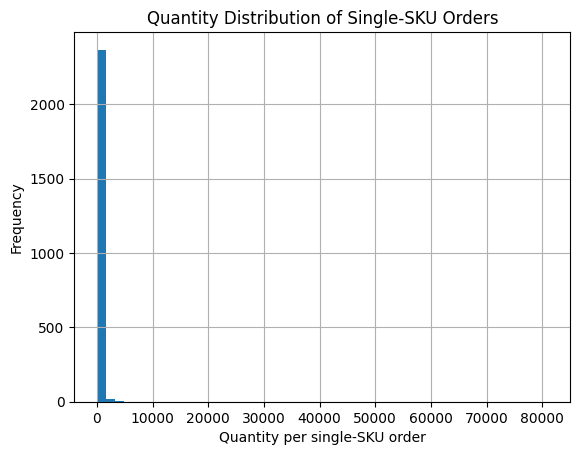

In [29]:
single_order_summary["total_quantity"].hist(
    bins=50
)

plt.xlabel("Quantity per single-SKU order")
plt.ylabel("Frequency")
plt.title("Quantity Distribution of Single-SKU Orders")
plt.show()

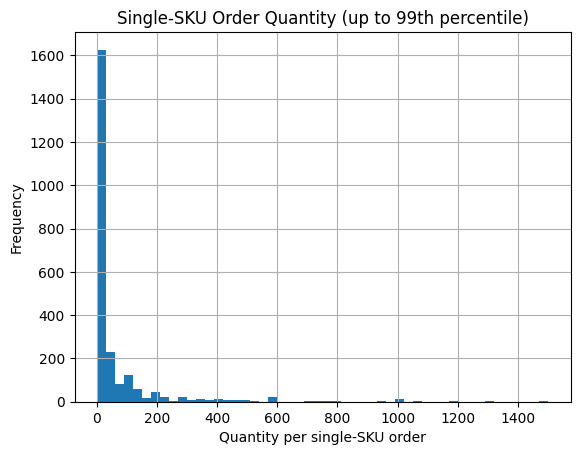

In [30]:
q99 = single_order_summary["total_quantity"].quantile(0.99)

single_order_summary[
    single_order_summary["total_quantity"] <= q99
]["total_quantity"].hist(bins=50)

plt.xlabel("Quantity per single-SKU order")
plt.ylabel("Frequency")
plt.title("Single-SKU Order Quantity (up to 99th percentile)")
plt.show()

In [37]:
qty = single_order_summary["total_quantity"]

print("100개 미만:", (qty < 100).sum())
print("100개 이상:", (qty >= 100).sum())
print("200개 이상:", (qty >= 200).sum())
print("500개 이상:", (qty >= 500).sum())
print("1000개 이상:", (qty >= 1000).sum())

100개 미만: 1979
100개 이상: 411
200개 이상: 231
500개 이상: 103
1000개 이상: 51


In [38]:
thresholds = [
    ("100개 미만", qty < 100),
    ("100개 이상", qty >= 100),
    ("200개 이상", qty >= 200),
    ("500개 이상", qty >= 500),
    ("1000개 이상", qty >= 1000)
]

for label, condition in thresholds:
    count = condition.sum()
    ratio = count / len(qty) * 100
    print(f"{label}: {count}건 ({ratio:.2f}%)")

100개 미만: 1979건 (82.80%)
100개 이상: 411건 (17.20%)
200개 이상: 231건 (9.67%)
500개 이상: 103건 (4.31%)
1000개 이상: 51건 (2.13%)


In [39]:
qty = single_order_summary["total_quantity"]

bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
labels = [
    "1-10", "11-20", "21-30", "31-40", "41-50",
    "51-60", "61-70", "71-80", "81-90", "91-100"
]

qty_100 = qty[qty <= 100]

grouped = pd.cut(
    qty_100,
    bins=bins,
    labels=labels,
    include_lowest=True
)

count = grouped.value_counts().sort_index()
ratio = grouped.value_counts(normalize=True).sort_index() * 100

result = pd.DataFrame({
    "count": count,
    "percentage": ratio
})

display(result)

,count,percentage
total_quantity,,
1-10,1154,56.903353
11-20,297,14.644970
21-30,175,8.629191
31-40,90,4.437870
41-50,108,5.325444
51-60,33,1.627219
61-70,20,0.986193
71-80,51,2.514793
81-90,9,0.443787


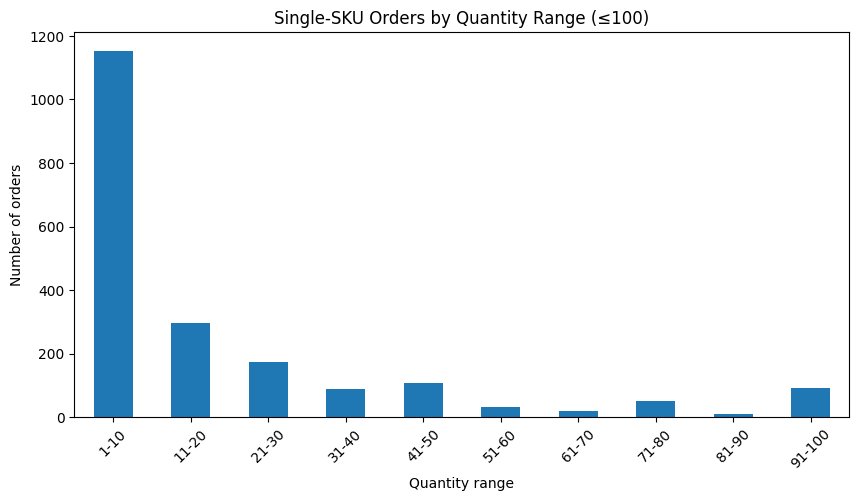

In [40]:
result["count"].plot(kind="bar", figsize=(10, 5))

plt.xlabel("Quantity range")
plt.ylabel("Number of orders")
plt.title("Single-SKU Orders by Quantity Range (≤100)")
plt.xticks(rotation=45)
plt.show()

In [43]:
qty = single_order_summary["total_quantity"]

# 1~10개만 추출
qty_10 = qty[(qty >= 1) & (qty <= 10)]

count_1_10 = (
    qty_10
    .value_counts()
    .sort_index()
)

result_1_10 = pd.DataFrame({
    "count": count_1_10,
    "percentage_within_1_10": count_1_10 / len(qty_10) * 100,
    "percentage_of_all": count_1_10 / len(qty) * 100
})

display(result_1_10.round(2))

,count,percentage_within_1_10,percentage_of_all
total_quantity,,,
1,497,43.07,20.79
2,179,15.51,7.49
3,87,7.54,3.64
4,113,9.79,4.73
5,50,4.33,2.09
6,88,7.63,3.68
7,12,1.04,0.50
8,41,3.55,1.72
9,21,1.82,0.88


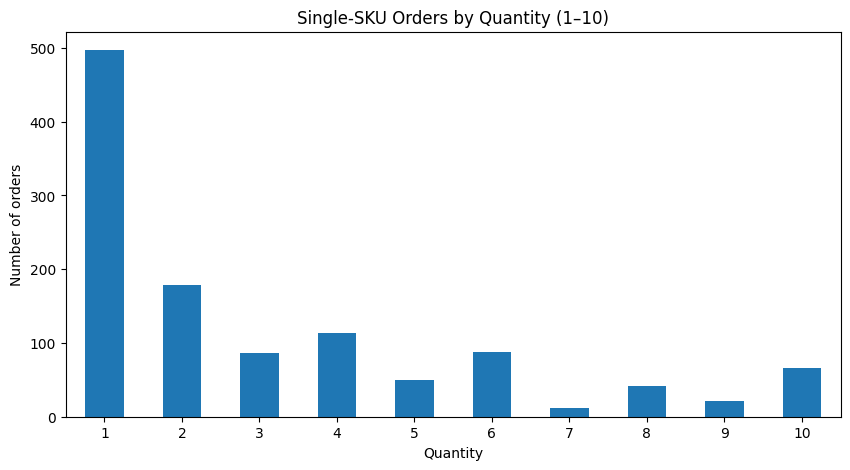

In [42]:
result_1_10["count"].plot(kind="bar", figsize=(10, 5))

plt.xlabel("Quantity")
plt.ylabel("Number of orders")
plt.title("Single-SKU Orders by Quantity (1–10)")
plt.xticks(rotation=0)
plt.show()

그래도 1개 산 사람이 많긴하네요

### B2B 주문 분리가 가능할지? 

In [44]:
# 고객별 거래 특성 생성
customer_summary = (
    uci.groupby("CustomerID")
       .agg(
           n_orders=("InvoiceNo", "nunique"),
           total_quantity=("Quantity", "sum"),
           avg_quantity=("Quantity", "mean"),
           max_quantity=("Quantity", "max"),
           total_spending=("UnitPrice", lambda x: 0)  # 아래에서 따로 계산
       )
)

In [45]:
uci["sales"] = uci["Quantity"] * uci["UnitPrice"]

customer_summary = (
    uci.groupby("CustomerID")
       .agg(
           n_orders=("InvoiceNo", "nunique"),
           total_quantity=("Quantity", "sum"),
           avg_quantity=("Quantity", "mean"),
           max_quantity=("Quantity", "max"),
           total_spending=("sales", "sum")
       )
)

In [ ]:
# 반복 주문도 많고 구매량도 큰 고객을 임시로:
wholesale_like = customer_summary[
    (customer_summary["n_orders"] >= customer_summary["n_orders"].quantile(0.75)) &
    (customer_summary["total_quantity"] >= customer_summary["total_quantity"].quantile(0.75))
]

print(len(wholesale_like))

790


In [ ]:
# 그 고객들만 다시 원자료에서 가져와서:

uci_wholesale_like = uci[
    uci["CustomerID"].isin(wholesale_like.index)
].copy()

In [ ]:
# 거기서 다시 주문당 distinct SKU 수 

b2b_like_sku_count = (
    uci_wholesale_like
    .groupby("InvoiceNo")["StockCode"]
    .nunique()
)
      
b2b_like_ratio = (
    b2b_like_sku_count
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

display(b2b_like_ratio.head(30))

StockCode
1     8.137236
2     4.014238
3     3.717619
4     3.519873
5     3.450662
6     3.074946
7     2.857425
8     2.758553
9     2.916749
10    2.590469
11    2.689342
12    2.501483
13    2.610243
14    2.541032
15    2.837651
16    2.906862
17    2.432272
18    2.570694
19    2.501483
20    2.293850
21    2.204865
22    1.878584
23    1.839035
24    1.661064
25    1.423769
26    1.384220
27    1.492980
28    1.176587
29    1.413882
30    1.156812
Name: proportion, dtype: float64

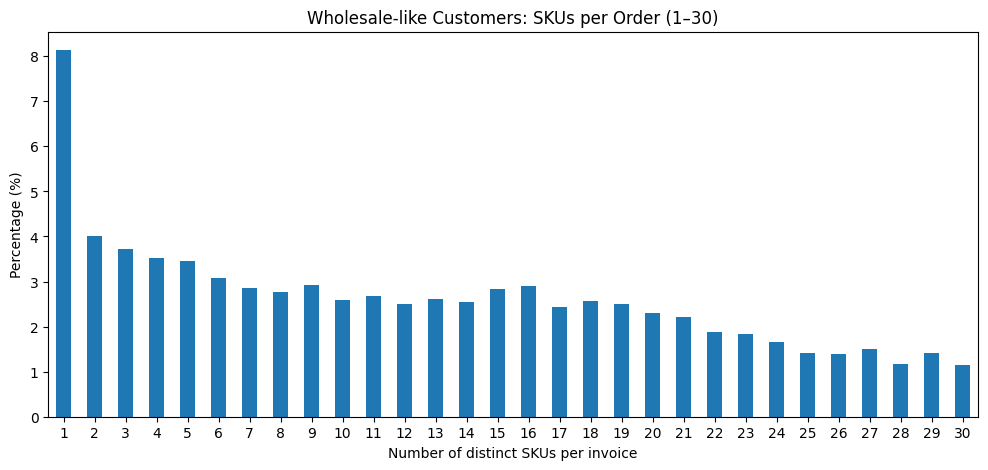

In [50]:
ratio_30 = b2b_like_ratio[b2b_like_ratio.index <= 30]

plt.figure(figsize=(12, 5))

ratio_30.plot(kind="bar")

plt.xlabel("Number of distinct SKUs per invoice")
plt.ylabel("Percentage (%)")
plt.title("Wholesale-like Customers: SKUs per Order (1–30)")
plt.xticks(rotation=0)

plt.show()

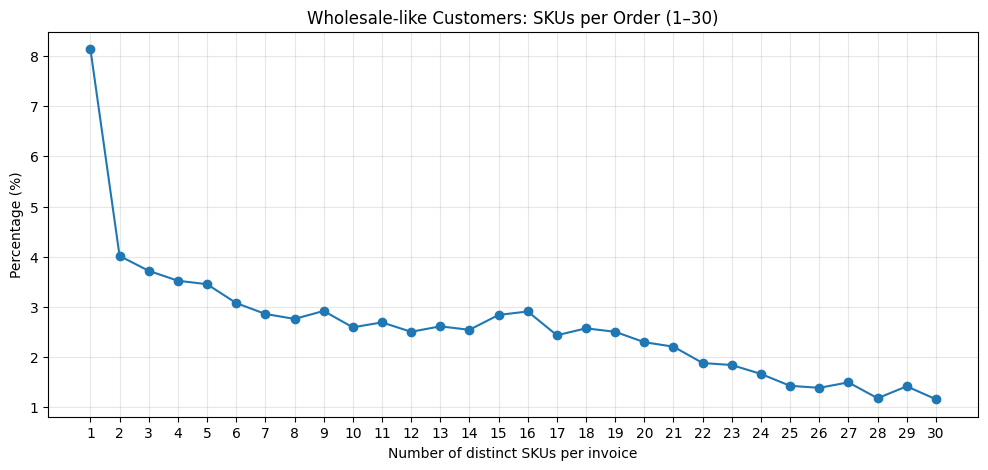

In [51]:
ratio_30 = b2b_like_ratio[b2b_like_ratio.index <= 30]

plt.figure(figsize=(12, 5))

plt.plot(
    ratio_30.index,
    ratio_30.values,
    marker="o"
)

plt.xlabel("Number of distinct SKUs per invoice")
plt.ylabel("Percentage (%)")
plt.title("Wholesale-like Customers: SKUs per Order (1–30)")
plt.xticks(range(1, 31))
plt.grid(alpha=0.3)

plt.show()

상위 25% = B2B라는 근거는 없기 때문에 바로 최종 기준으로 삼기는 애매. 

전체 UCI → 고객별 행동 특성 확인 → 실제로 고객군이 몇 개로 나뉘는지 확인 → wholesale-like cluster 추출 → 그 cluster의 SKU/Quantity 분포 분석

하는게 좋을듯

In [52]:
# wholesale-like 고객의 주문별 SKU 수
b2b_invoice_summary = (
    uci_wholesale_like
    .groupby("InvoiceNo")
    .agg(
        sku_count=("StockCode", "nunique"),
        total_quantity=("Quantity", "sum")
    )
)

# 그중 1-SKU 주문만
b2b_single = b2b_invoice_summary[
    b2b_invoice_summary["sku_count"] == 1
]

b2b_single["total_quantity"].describe(
    percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
)

count     823.000000
mean      115.816525
std       260.446176
min         1.000000
50%        23.000000
75%        96.000000
90%       332.800000
95%       576.000000
99%      1200.000000
max      2400.000000
Name: total_quantity, dtype: float64

In [53]:
print("1개만 구매:",
      (b2b_single["total_quantity"] == 1).sum())

print("10개 이상:",
      (b2b_single["total_quantity"] >= 10).sum())

print("100개 이상:",
      (b2b_single["total_quantity"] >= 100).sum())

print("500개 이상:",
      (b2b_single["total_quantity"] >= 500).sum())

1개만 구매: 97
10개 이상: 566
100개 이상: 205
500개 이상: 50
